In [1]:
import numpy as np  
import matplotlib.pyplot as plt
import pandas as pd 
import astropy.io 
import scipy.stats
import requests
from sklearn.decomposition import PCA


In [3]:
import urllib.request
import ssl
import certifi

ssl_context = ssl.create_default_context(cafile=certifi.where())

# Usa urlopen() per aprire il link con il contesto SSL
with urllib.request.urlopen("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", context=ssl_context) as response:
    with open("stars.csv", "wb") as f:
        f.write(response.read())

Let's read the see the data 

In [5]:
df_stars = pd.read_csv("stars.csv")
df_stars

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,Brown Dwarf,Red,M
1,3042,0.000500,0.1542,16.60,Brown Dwarf,Red,M
2,2600,0.000300,0.1020,18.70,Brown Dwarf,Red,M
3,2800,0.000200,0.1600,16.65,Brown Dwarf,Red,M
4,1939,0.000138,0.1030,20.06,Brown Dwarf,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,Hypergiant,Blue,O
236,30839,834042.000000,1194.0000,-10.63,Hypergiant,Blue,O
237,8829,537493.000000,1423.0000,-10.73,Hypergiant,White,A
238,9235,404940.000000,1112.0000,-11.23,Hypergiant,White,A


Trasforming the star type into an integer

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Assign unique integers from 0 to 6 to each star type
df_stars['Star type'] = le.fit_transform(df_stars['Star type'])
labels = le.inverse_transform(df_stars['Star type'])                            #they are 0,1,2,3,4,5
class_names = le.classes_
print(class_names) 


['Brown Dwarf' 'Hypergiant' 'Main Sequence' 'Red Dwarf' 'Supergiant'
 'White Dwarf']


### Plot the HR diagram

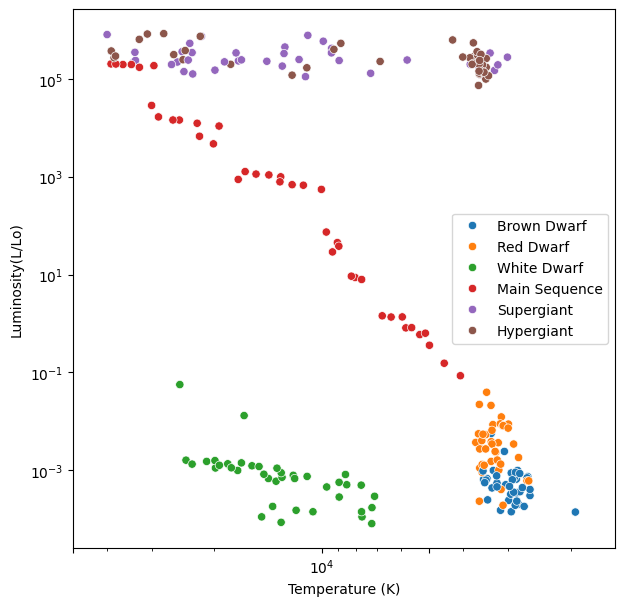

In [9]:
import seaborn as sns

fig = plt.figure(figsize=(7, 7))
sns.scatterplot(data=df_stars, x='Temperature (K)', y='Luminosity(L/Lo)', hue=labels)

plt.xscale('log')
plt.yscale('log')
plt.xticks([5000, 10000, 50000])
plt.xlim(5e4, 1.5e3) #swiches the axis 
plt.show()


In [14]:
# Blind the data 
df_stars_data = df_stars.drop(['Star type', 'Star color', 'Spectral Class'], axis=1)
X = np.array(df_stars_data)

In [24]:
# FIT TRANSFORM: Fit the model with X and apply the dimensionality reduction on X
# FIT instedd calculates the mean, the principal components, the variances...
n_components = 2  
pca = PCA(n_components=2)
projected_stars = pca.fit_transform(X) 

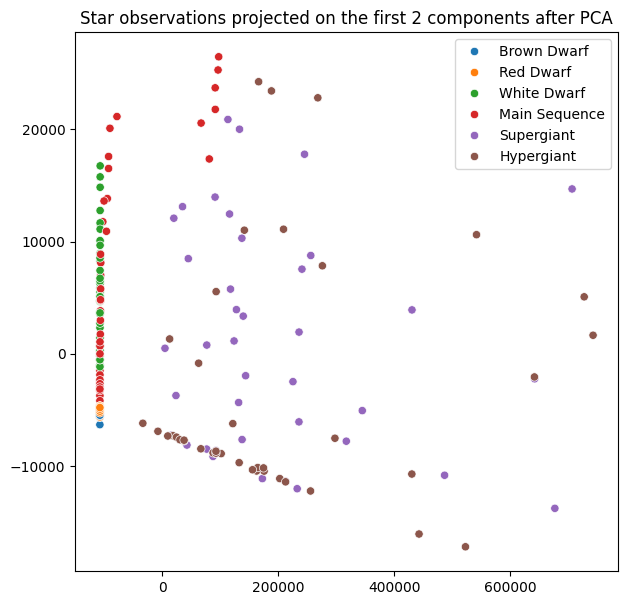

In [18]:
fig = plt.figure(figsize=(7, 7))
sns.scatterplot(x=projected_stars[:,0], y=projected_stars[:,1], hue=labels)
plt.title("Star observations projected on the first 2 components after PCA")
plt.show()

#### It is ugly! First RESCALE the data

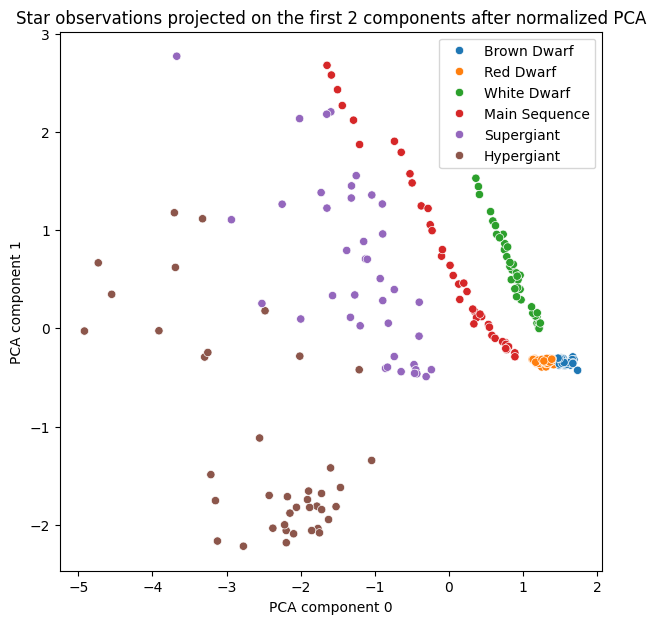

In [ ]:
from sklearn.preprocessing import StandardScaler

#Standardize features by removing the mean and scaling to unit variance.
scaler = StandardScaler()
X = scaler.fit_transform(df_stars_data)

# without the number of components, PCA will keep all the components
pca_n = PCA()
projected_stars = pca_n.fit_transform(X)

fig = plt.figure(figsize=(7, 7))
sns.scatterplot(x=projected_stars[:,0], y=projected_stars[:,1], hue=labels)
plt.xlabel("PCA component 0")
plt.ylabel("PCA component 1")

plt.title("Star observations projected on the first 2 components after normalized PCA")
plt.show()

Much better now! The component 0 and 1 (combination of the features are more informative than Temperature and Luminosity)

In [28]:
s = 0
for idx, r in enumerate(pca_n.explained_variance_ratio_):
    s += r #for the cumulative 
    print(f"Component {idx+1} explains {100*r:.1f}% of the variance (cumulative = {100*s:.1f})%")

Component 1 explains 60.4% of the variance (cumulative = 60.4)%
Component 2 explains 23.5% of the variance (cumulative = 83.9)%
Component 3 explains 9.3% of the variance (cumulative = 93.2)%
Component 4 explains 6.8% of the variance (cumulative = 100.0)%


### Scree plots

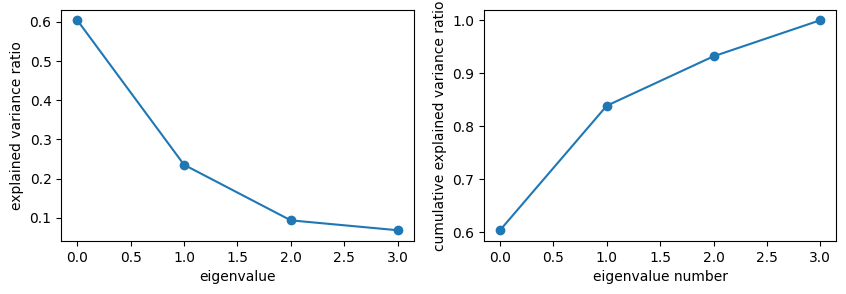

In [31]:
evals = pca_n.explained_variance_ratio_ 
N_Comp= len(evals)

fig = plt.figure(figsize=(10, 3))

ax = fig.add_subplot(121)

ax.plot(np.arange(N_Comp), evals)
ax.scatter(np.arange(N_Comp), evals)

ax.set_xlabel("eigenvalue")
ax.set_ylabel("explained variance ratio")

ax = fig.add_subplot(122)

ax.plot(np.arange(N_Comp), evals.cumsum())
ax.scatter(np.arange(N_Comp), evals.cumsum())

ax.set_xlabel("eigenvalue number")
ax.set_ylabel("cumulative explained variance ratio")

plt.show()

Let's plot how adding pca component we get closer and closer to the original point

[-2.77205884 -2.2194581  -0.23477768  0.19141102]


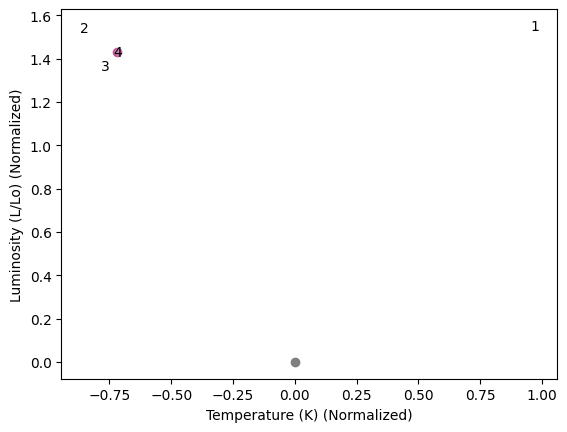

In [115]:
n_obj=56
star = X[n_obj]         #one star selection
mean=pca_n.mean_  #mean of the data
eigenvectors = pca_n.components_ #pca components
star_pca = projected_stars[n_obj]       #the projection of the star on the pca components
print(star_pca)

x1 = mean + star_pca[0] * eigenvectors[0] 
x2 = mean + star_pca[1] * eigenvectors[1] + x1
x3 = mean + star_pca[2] * eigenvectors[2] + x2
x4 = mean + star_pca[3] * eigenvectors[3] + x3

#with the direct function of pca
X_rec = pca_n.inverse_transform(projected_stars)

plt.scatter(X_rec[n_obj, 0], X_rec[n_obj, 1], color='blue', label='Reconstructed Stars', alpha=0.3)

plt.scatter(star[0], star[1], color='red', label='Star 1', alpha=0.3)
plt.scatter(mean[0], mean[1], color='grey', label='Mean') 
plt.scatter(x1[0], x1[1], label='mean + 1 component', alpha=0)
plt.text(x1[0], x1[1], '1', fontsize=10, ha='center', va='center')
plt.scatter(x2[0], x2[1], label='mean + 2 components', alpha=0)
plt.text(x2[0], x2[1], '2', fontsize=10, ha='center', va='center')
plt.scatter(x3[0], x3[1], label='mean + 3 components', alpha=0)
plt.text(x3[0], x3[1], '3', fontsize=10, ha='center', va='center')   
plt.scatter(x4[0], x4[1], label='mean + 4 components', alpha=0) 
plt.text(x4[0], x4[1], '4', fontsize=10, ha='center', va='center')
plt.xlabel('Temperature (K) (Normalized)') 
plt.ylabel('Luminosity (L/Lo) (Normalized)') 
plt.show()

